In [1]:
import pandas as pd

movies = pd.read_csv("../data/movies.csv")
ratings = pd.read_csv("../data/ratings.csv")

In [3]:
ratings.head()


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [4]:
ratings.shape

(100836, 4)

In [5]:
ratings['userId'].nunique()

610

In [6]:
ratings['movieId'].nunique()

9724

In [7]:
movie_ratings = pd.merge(
    ratings,
    movies,
    on='movieId'
)

movie_ratings.head()

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [8]:
movie_ratings.shape

(100836, 6)

In [9]:
movie_ratings.head()

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [10]:
user_movie_matrix = movie_ratings.pivot_table(
    index='title',
    columns='userId',
    values='rating'
)

user_movie_matrix.head()

userId,1,2,3,4,5,6,7,8,9,10,...,601,602,603,604,605,606,607,608,609,610
title,,,,,,,,,,,,,,,,,,,,,
'71 (2014),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0
'Hellboy': The Seeds of Creation (2004),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
'Round Midnight (1986),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
'Salem's Lot (2004),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
'Til There Was You (1997),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
user_movie_matrix.shape

(9719, 610)

In [12]:
user_movie_matrix.isna().sum().sum()

np.int64(5827758)

In [13]:
user_movie_matrix_filled = user_movie_matrix.fillna(0)

user_movie_matrix_filled.head()

userId,1,2,3,4,5,6,7,8,9,10,...,601,602,603,604,605,606,607,608,609,610
title,,,,,,,,,,,,,,,,,,,,,
'71 (2014),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0
'Hellboy': The Seeds of Creation (2004),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
'Round Midnight (1986),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
'Salem's Lot (2004),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
'Til There Was You (1997),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [14]:
from sklearn.neighbors import NearestNeighbors

knn = NearestNeighbors(
    metric='cosine',
    algorithm='brute'
)

knn.fit(user_movie_matrix_filled)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"radius radius: float, default=1.0Range of parameter space to use by default for :meth:`radius_neighbors`queries.",1.0
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'brute'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'cosine'
,"p p: float (positive), default=2Parameter for the Minkowski metric fromsklearn.metrics.pairwise.pairwise_distances. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [15]:
def recommend_movie(movie_name):
    
    movie_index = user_movie_matrix_filled.index.get_loc(movie_name)

    distances, indices = knn.kneighbors(
        user_movie_matrix_filled.iloc[movie_index].values.reshape(1, -1),
        n_neighbors=6
    )

    print("Recommended Movies:\n")

    for i in range(1, len(indices[0])):
        print(user_movie_matrix_filled.index[indices[0][i]])

In [16]:
recommend_movie("Toy Story (1995)")

Recommended Movies:

Toy Story 2 (1999)
Jurassic Park (1993)
Independence Day (a.k.a. ID4) (1996)
Star Wars: Episode IV - A New Hope (1977)
Forrest Gump (1994)


In [17]:
recommend_movie("Jumanji (1995)")

Recommended Movies:

Lion King, The (1994)
Mrs. Doubtfire (1993)
Mask, The (1994)
Jurassic Park (1993)
Home Alone (1990)


In [18]:
recommend_movie("iron man")

KeyError: 'iron man'

In [19]:
movies[movies['title'].str.contains("Iron", case=False, na=False)][['title']].head(20)

,title
1331,"Man in the Iron Mask, The (1998)"
2077,"Iron Giant, The (1999)"
2118,Iron Eagle (1986)
2119,Iron Eagle II (1988)
2120,Aces: Iron Eagle III (1992)
2121,Iron Eagle IV (1995)
3354,"Tetsuo, the Ironman (Tetsuo) (1988)"
3542,Iron Monkey (Siu nin Wong Fei-hung ji: Tit Ma ...
3822,Iron Will (1994)
4840,Pumping Iron (1977)


In [20]:
recommend_movie("Iron Man (2008)")

Recommended Movies:

Dark Knight, The (2008)
WALL·E (2008)
Avengers, The (2012)
Iron Man 2 (2010)
Avatar (2009)


In [21]:
movie_ratings.groupby('title')['rating'].count().sort_values(ascending=False).head(10)

title
Forrest Gump (1994)                          329
Shawshank Redemption, The (1994)             317
Pulp Fiction (1994)                          307
Silence of the Lambs, The (1991)             279
Matrix, The (1999)                           278
Star Wars: Episode IV - A New Hope (1977)    251
Jurassic Park (1993)                         238
Braveheart (1995)                            237
Terminator 2: Judgment Day (1991)            224
Schindler's List (1993)                      220
Name: rating, dtype: int64

In [22]:
movie_ratings.groupby('title')['rating'].mean().sort_values(ascending=False).head(10)

title
Gena the Crocodile (1969)                    5.0
True Stories (1986)                          5.0
Cosmic Scrat-tastrophe (2015)                5.0
Love and Pigeons (1985)                      5.0
Red Sorghum (Hong gao liang) (1987)          5.0
Thin Line Between Love and Hate, A (1996)    5.0
Lesson Faust (1994)                          5.0
Eva (2011)                                   5.0
Who Killed Chea Vichea? (2010)               5.0
Siam Sunset (1999)                           5.0
Name: rating, dtype: float64

In [23]:
movie_stats = movie_ratings.groupby('title')['rating'].agg(['mean', 'count'])

movie_stats.head()

,mean,count
title,,
'71 (2014),4.0,1
'Hellboy': The Seeds of Creation (2004),4.0,1
'Round Midnight (1986),3.5,2
'Salem's Lot (2004),5.0,1
'Til There Was You (1997),4.0,2


In [24]:
movie_stats.sort_values('count', ascending=False).head(10)

,mean,count
title,,
Forrest Gump (1994),4.164134,329
"Shawshank Redemption, The (1994)",4.429022,317
Pulp Fiction (1994),4.197068,307
"Silence of the Lambs, The (1991)",4.161290,279
"Matrix, The (1999)",4.192446,278
Star Wars: Episode IV - A New Hope (1977),4.231076,251
Jurassic Park (1993),3.750000,238
Braveheart (1995),4.031646,237
Terminator 2: Judgment Day (1991),3.970982,224


In [25]:
movie_stats.sort_values('mean', ascending=False).head(10)

,mean,count
title,,
Gena the Crocodile (1969),5.0,1
True Stories (1986),5.0,1
Cosmic Scrat-tastrophe (2015),5.0,1
Love and Pigeons (1985),5.0,1
Red Sorghum (Hong gao liang) (1987),5.0,1
"Thin Line Between Love and Hate, A (1996)",5.0,1
Lesson Faust (1994),5.0,2
Eva (2011),5.0,1
Who Killed Chea Vichea? (2010),5.0,1


In [26]:
popular_movies = movie_stats[
    movie_stats['count'] >= 100
]

popular_movies.sort_values(
    'mean',
    ascending=False
).head(20)

,mean,count
title,,
"Shawshank Redemption, The (1994)",4.429022,317
"Godfather, The (1972)",4.289062,192
Fight Club (1999),4.272936,218
"Godfather: Part II, The (1974)",4.259690,129
"Departed, The (2006)",4.252336,107
Goodfellas (1990),4.250000,126
Casablanca (1942),4.240000,100
"Dark Knight, The (2008)",4.238255,149
"Usual Suspects, The (1995)",4.237745,204


In [27]:
movie_stats['popularity_score'] = (
    movie_stats['mean'] * movie_stats['count']
)

In [28]:
movie_stats.sort_values(
    'popularity_score',
    ascending=False
).head(20)

,mean,count,popularity_score
title,,,
"Shawshank Redemption, The (1994)",4.429022,317,1404.0
Forrest Gump (1994),4.164134,329,1370.0
Pulp Fiction (1994),4.197068,307,1288.5
"Matrix, The (1999)",4.192446,278,1165.5
"Silence of the Lambs, The (1991)",4.161290,279,1161.0
Star Wars: Episode IV - A New Hope (1977),4.231076,251,1062.0
Braveheart (1995),4.031646,237,955.5
Fight Club (1999),4.272936,218,931.5
Schindler's List (1993),4.225000,220,929.5


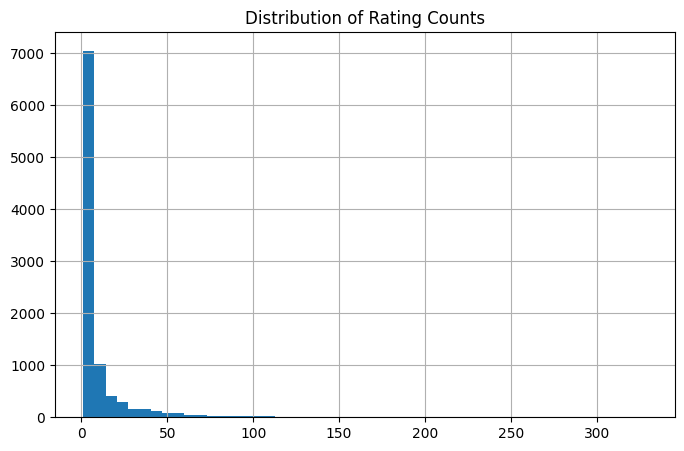

In [29]:
import matplotlib.pyplot as plt

movie_stats['count'].hist(
    bins=50,
    figsize=(8,5)
)

plt.title("Distribution of Rating Counts")
plt.show()

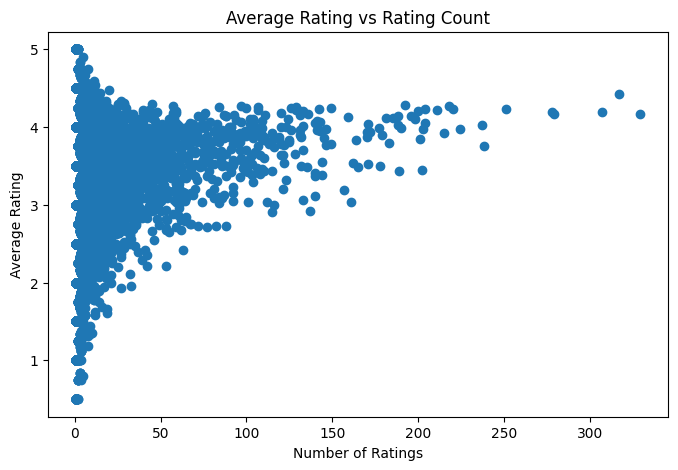

In [30]:
plt.figure(figsize=(8,5))

plt.scatter(
    movie_stats['count'],
    movie_stats['mean']
)

plt.xlabel("Number of Ratings")
plt.ylabel("Average Rating")
plt.title("Average Rating vs Rating Count")

plt.show()

In [31]:
def top_popular_movies(n=10):
    result = movie_stats[
        movie_stats['count'] >= 100
    ]

    return result.sort_values(
        'mean',
        ascending=False
    ).head(n)

In [32]:
top_popular_movies()

,mean,count,popularity_score
title,,,
"Shawshank Redemption, The (1994)",4.429022,317,1404.0
"Godfather, The (1972)",4.289062,192,823.5
Fight Club (1999),4.272936,218,931.5
"Godfather: Part II, The (1974)",4.259690,129,549.5
"Departed, The (2006)",4.252336,107,455.0
Goodfellas (1990),4.250000,126,535.5
Casablanca (1942),4.240000,100,424.0
"Dark Knight, The (2008)",4.238255,149,631.5
"Usual Suspects, The (1995)",4.237745,204,864.5


In [33]:
top_popular_movies(20)

,mean,count,popularity_score
title,,,
"Shawshank Redemption, The (1994)",4.429022,317,1404.0
"Godfather, The (1972)",4.289062,192,823.5
Fight Club (1999),4.272936,218,931.5
"Godfather: Part II, The (1974)",4.259690,129,549.5
"Departed, The (2006)",4.252336,107,455.0
Goodfellas (1990),4.250000,126,535.5
Casablanca (1942),4.240000,100,424.0
"Dark Knight, The (2008)",4.238255,149,631.5
"Usual Suspects, The (1995)",4.237745,204,864.5


In [34]:
top_popular_movies(20).to_csv(
    "top_movies.csv"
)